In [2]:
import os
from pathlib import Path
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from globals import main_dir,data_dir, plot_dir, res_dir
import plotting_routines


## Wake-Length  (\# Periods)

In [ ]:
# extracting data:
res_dir : Path

wake_length_dir = res_dir.joinpath('sensitivity/wake_length')

assert wake_length_dir.exists(), "Folder does not exist!"

wl_dfs = {}

for wl_file in os.listdir(wake_length_dir):
    wl_fpath = wake_length_dir.joinpath(wl_file)
    if wl_fpath.suffix != '.csv': continue
    if 'n=' not in wl_file: 
        wl_sum = pd.read_csv(wl_fpath)
    else:
        i = int(re.search(r'n=(\d+)', wl_file).group(1))
        wl_dfs[i] = pd.read_csv(wl_fpath)


#### Summary Plot

In [4]:
#  options
wl_sum.columns

Index(['i', 'CT', 'TC', 'CP', 'PC', 'CQ', 'QC', 'eta', 'it'], dtype='str')

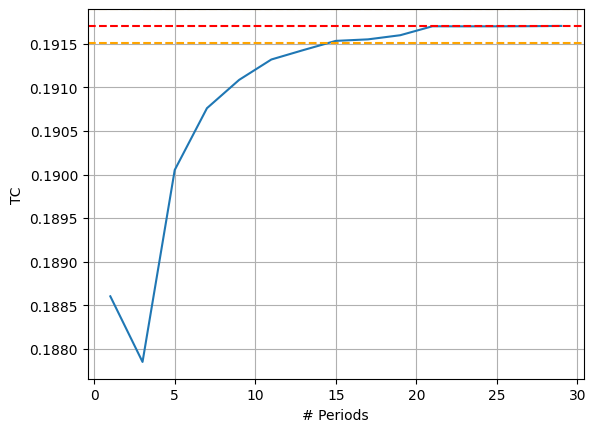

In [5]:
# summary plot
col = 'TC'
err_acc = 0.001
fig, ax = plt.subplots()

ax.plot(wl_sum['i'], wl_sum[col])
ax.set_ylabel(col)
ax.set_xlabel('# Periods')
ax.grid()

ax.axhline((1+err_acc)*wl_sum[col].to_list()[-1], ls='--', c='orange')
ax.axhline((1-err_acc)*wl_sum[col].to_list()[-1], ls='--', c='orange')
ax.axhline(wl_sum[col].to_list()[-1], ls='--', c='red')

fig.savefig(wake_length_dir.joinpath(f'dist_plot_{col}_wl.pdf'))


#### Distributions

In [6]:
# options

wl_dfs[1].columns

Index(['r_R', 'alpha', 'phi', 'Cl', 'Cd', 'gamma', 'Cy', 'Cx', 'a', 'aline',
       'V_i_x', 'V_i_y', 'V_i_z'],
      dtype='str')

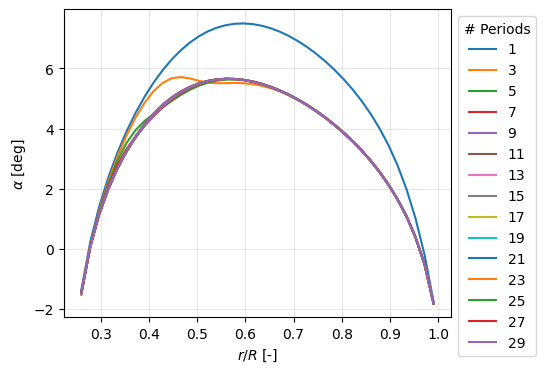

In [7]:
col = 'alpha'

fig, ax = plt.subplots(figsize=(5,4))

for i, wl_df in wl_dfs.items():
    plotting_routines.distribution(col, wl_df, ax, label=i)

ax.grid(True)
lgd = ax.legend(title='# Periods', bbox_to_anchor=(1, 1), loc='upper left')
fig.savefig(wake_length_dir.joinpath(f'dist_plot_{col}_wl.pdf'),
            bbox_extra_artists=(lgd,), bbox_inches='tight')


## Wake-Resolution

In [ ]:
# extracting data:
res_dir : Path

wake_res_dir = res_dir.joinpath('sensitivity/wake_res')

assert wake_res_dir.exists(), "Folder does not exist!"

wr_dfs = {}

for wr_file in os.listdir(wake_res_dir):
    wr_fpath = wake_res_dir.joinpath(wr_file)
    if wr_fpath.suffix != '.csv': continue
    if 'n=' not in wr_file: 
        wr_sum = pd.read_csv(wr_fpath)
    else:
        i = int(re.search(r'n=(\d+)', wr_file).group(1))
        wr_dfs[i] = pd.read_csv(wr_fpath)



#### Summary

In [9]:
#  options
wr_sum.columns

Index(['CT', 'TC', 'CP', 'PC', 'CQ', 'QC', 'eta', 'it', 'i'], dtype='str')

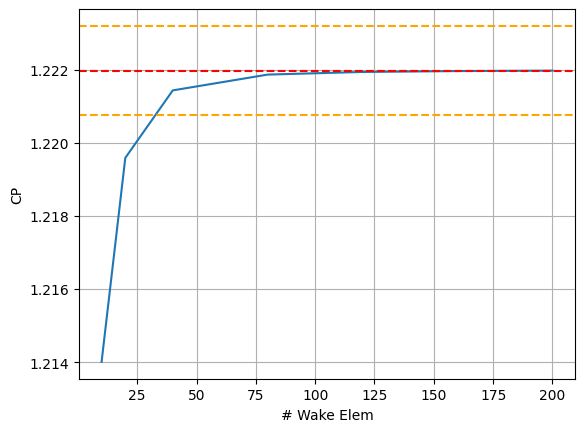

In [10]:
# summary plot
col = 'CP'
err_acc = 0.001
fig, ax = plt.subplots()

ax.plot(wr_sum['i'], wr_sum[col])
ax.set_ylabel(col)
ax.set_xlabel('# Wake Elem')
ax.grid()

ax.axhline((1+err_acc)*wr_sum[col].to_list()[-1], ls='--', c='orange')
ax.axhline((1-err_acc)*wr_sum[col].to_list()[-1], ls='--', c='orange')
ax.axhline(wr_sum[col].to_list()[-1], ls='--', c='red')

fig.savefig(wake_res_dir.joinpath(f'summary_plot_{col}_wr.pdf'))

#### Distributions

In [11]:
# options

wr_dfs[list(wr_dfs.keys())[0]].columns

Index(['r_R', 'alpha', 'phi', 'Cl', 'Cd', 'gamma', 'Cy', 'Cx', 'a', 'aline',
       'V_i_x', 'V_i_y', 'V_i_z'],
      dtype='str')

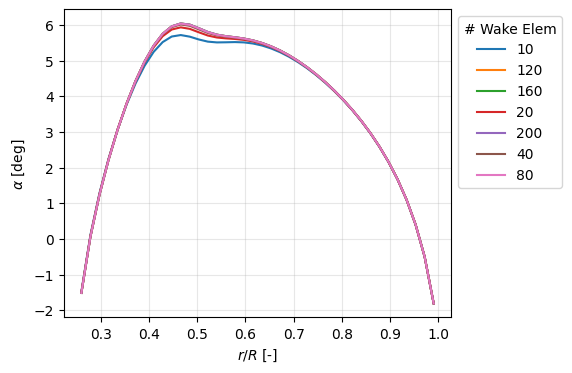

In [12]:
col = 'alpha'

fig, ax = plt.subplots(figsize=(5,4))

for i, wr_df in wr_dfs.items():
    plotting_routines.distribution(col, wr_df, ax, label=i)

ax.grid(True)
lgd = ax.legend(title='# Wake Elem', bbox_to_anchor=(1, 1), loc='upper left')
fig.savefig(wake_length_dir.joinpath(f'dist_plot_{col}_wr.pdf'),
            bbox_extra_artists=(lgd,), bbox_inches='tight')


## Blade Resolution

In [ ]:
# extracting data:
res_dir : Path

blade_res_dir = res_dir.joinpath('sensitivity/blade_res')

assert blade_res_dir.exists(), "Folder does not exist!"

br_dfs = {}
br_dfs_c = {}

for br_file in os.listdir(blade_res_dir):
    br_fpath = blade_res_dir.joinpath(br_file)
    if br_fpath.suffix != '.csv': continue
    if "_c." not in br_file:
        if 'n=' not in br_file: 
            br_sum = pd.read_csv(br_fpath)
        else:
            i = int(re.search(r'n=(\d+)', br_file).group(1))
            br_dfs[i] = pd.read_csv(br_fpath)
    else:
        if 'n=' not in br_file:     
            br_sum_c = pd.read_csv(br_fpath)
        else:
            i = int(re.search(r'n=(\d+)', br_file).group(1))
            br_dfs_c[i] = pd.read_csv(br_fpath)


#### Summary

In [14]:
#  options
br_sum.columns

Index(['i', 'CT', 'TC', 'CP', 'PC', 'CQ', 'QC', 'eta', 'it'], dtype='str')

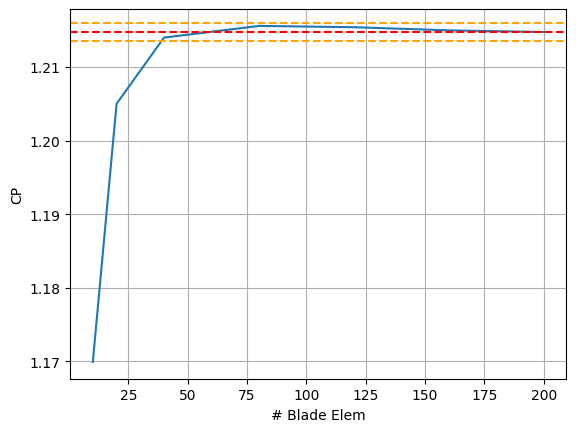

In [ ]:
# summary plot
col = 'CP'
err_acc = 0.001
fig, ax = plt.subplots()

ax.plot(br_sum['i'], br_sum[col], label='uniform')
ax.plot(br_sum_c['i'], br_sum_c[col], label='cosine')
ax.set_ylabel(col)
ax.set_xlabel('# Blade Elem')
ax.grid()
ax.legend()
# ax.axhline((1+err_acc)*br_sum[col].to_list()[-1], ls='--', c='orange')
# ax.axhline((1-err_acc)*br_sum[col].to_list()[-1], ls='--', c='orange')
# ax.axhline(br_sum[col].to_list()[-1], ls='--', c='red')

fig.savefig(blade_res_dir.joinpath(f'summary_plot_{col}_br.pdf'))

#### Distribution

In [16]:
# options

br_dfs[list(br_dfs.keys())[0]].columns

Index(['r_R', 'alpha', 'phi', 'Cl', 'Cd', 'gamma', 'Cy', 'Cx', 'a', 'aline',
       'V_i_x', 'V_i_y', 'V_i_z'],
      dtype='str')

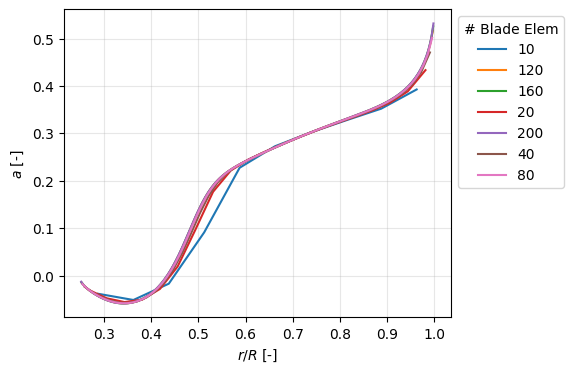

In [17]:
col = 'a'

fig, ax = plt.subplots(figsize=(5,4))

for i, br_df in br_dfs.items():
    plotting_routines.distribution(col, br_df, ax, label=i)

ax.grid(True)
lgd = ax.legend(title='# Blade Elem', bbox_to_anchor=(1, 1), loc='upper left')
fig.savefig(wake_length_dir.joinpath(f'dist_plot_{col}_br.pdf'),
            bbox_extra_artists=(lgd,), bbox_inches='tight')

# a_wake

In [ ]:
a_wake_res_dir = res_dir.joinpath('sensitivity/a_wake')

assert a_wake_res_dir.exists(), "Folder does not exist!"

aw_dfs = {}

for aw_file in os.listdir(a_wake_res_dir):
    aw_fpath = a_wake_res_dir.joinpath(aw_file)
    if aw_fpath.suffix != '.csv': continue

    if 'n=' not in aw_file: 
        aw_sum = pd.read_csv(aw_fpath)
    else:
        i = str(re.search(r'n=([0-9]*\.?[0-9]+)', aw_file).group(1))[:4]
        aw_dfs[i] = pd.read_csv(aw_fpath)

11


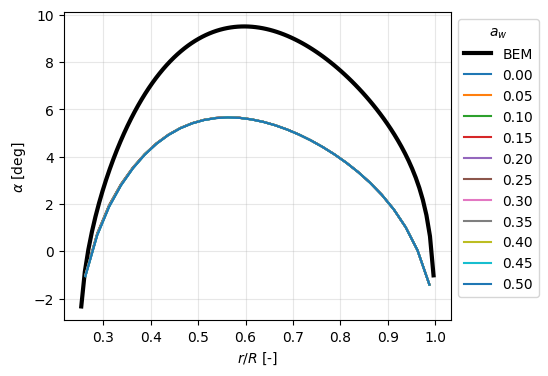

In [19]:
col = 'alpha'

fig, ax = plt.subplots(figsize=(5,4))
print(len(aw_dfs.items()))
bem_data = pd.read_csv("data/BEM_data_1.2.csv")
plt.plot(bem_data["r_R"], bem_data["alpha"],label = "BEM",color="black",linewidth=3)
for i, aw_df in aw_dfs.items():
    plotting_routines.distribution(col, aw_df, ax, label=i)

ax.grid(True)
lgd = ax.legend(title=r'$a_w$', bbox_to_anchor=(1, 1), loc='upper left')
fig.savefig(a_wake_res_dir.joinpath(f'dist_plot_{col}_aw.pdf'),
            bbox_extra_artists=(lgd,), bbox_inches='tight')

# Short wake

11


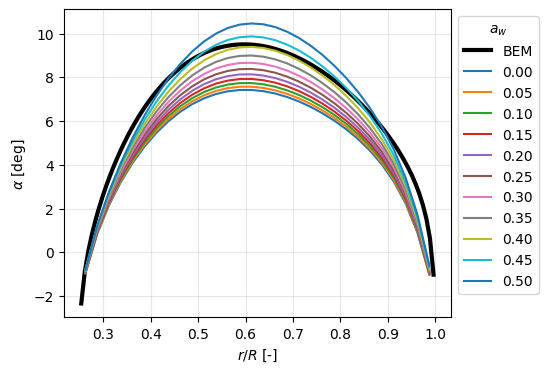

In [ ]:
a_wake_res_dir = res_dir.joinpath('sensitivity/a_short_wake')

assert a_wake_res_dir.exists(), "Folder does not exist!"

asw_dfs = {}

for asw_file in os.listdir(a_wake_res_dir):
    asw_fpath = a_wake_res_dir.joinpath(asw_file)
    if asw_fpath.suffix != '.csv': continue
    if 'n=' not in asw_file: 
        asw_sum = pd.read_csv(asw_fpath)
    else:
        i = str(re.search(r'n=([0-9]*\.?[0-9]+)', asw_file).group(1))[:4]
        asw_dfs[i] = pd.read_csv(asw_fpath)

col = 'alpha'

fig, ax = plt.subplots(figsize=(5,4))
print(len(asw_dfs.items()))
bem_data = pd.read_csv("data/BEM_data_1.2.csv")
plt.plot(bem_data["r_R"], bem_data["alpha"],label = "BEM",color="black",linewidth=3)
for i, asw_df in asw_dfs.items():
    plotting_routines.distribution(col, asw_df, ax, label=i)

ax.grid(True)
lgd = ax.legend(title=r'$a_w$', bbox_to_anchor=(1, 1), loc='upper left')
fig.savefig(a_wake_res_dir.joinpath(f'dist_plot_{col}_asw.pdf'),
            bbox_extra_artists=(lgd,), bbox_inches='tight')